## 2.2 Anisotropic stiffness blocks and Hamiltonian $H(\theta;\lambda)$

We follow Recho’s Hamiltonian formalism for crack-tip fields.   

The starting point is a $3 \times 3$ stiffness matrix $C$ in the $(r,\theta)$ polar Voigt basis
for plane problems,
$$
C =
\begin{pmatrix}
c_{11} & c_{12} & c_{14} \\
c_{21} & c_{22} & c_{24} \\
c_{41} & c_{42} & c_{44}
\end{pmatrix},
$$
where $c_{ij}$ are already expressed in the crack-aligned polar frame.

From $C$ we build the $2\times 2$ stiffness sub-blocks (Eq. (36) in the paper):
$$
C_d =
\begin{pmatrix}
c_{22} & c_{24} \\
c_{42} & c_{44}
\end{pmatrix},
\qquad
C_e =
\begin{pmatrix}
- c_{24} & c_{22} \\
- c_{44} & c_{42}
\end{pmatrix},
\qquad
C_f =
\begin{pmatrix}
c_{24} & c_{21} \\
c_{44} & c_{41}
\end{pmatrix}.
$$

We also use the $2\times 2$ matrices
$$
E_1 =
\begin{pmatrix}
0 & -1 \\
1 & 0
\end{pmatrix},
\quad
E_2 =
\begin{pmatrix}
0 & -1 \\
0 & 0
\end{pmatrix},
\quad
E_3 =
\begin{pmatrix}
0 & 0 \\
-1 & 0
\end{pmatrix}.
$$

After introducing the radial coordinate $\xi = \ln r$ and the separable ansatz
$$
v(\xi,\theta) = e^{\lambda \xi}\,\psi(\theta),
$$
the governing equations reduce to a $\theta$-only Hamiltonian system
$$
\frac{d\psi}{d\theta} = H(\theta,\lambda)\,\psi(\theta),
$$
where $\lambda$ is the singularity exponent and $\psi(\theta)$ collects the
displacement and stress components.

Recho’s Eq. (46) gives the Hamiltonian matrix as
$$
H(\theta,\lambda) =
\begin{pmatrix}
E_1 - C_d^{-1} C_f\,\lambda & C_d^{-1} \\
E_3 (C_d^{-1} C_f)\,\lambda^2 & E_1 + (E_2 + E_3 C_d^{-1})\,\lambda
\end{pmatrix}.
$$

This section implements a **generic map**
$$
C \longrightarrow (C_d, C_e, C_f) \longrightarrow H(\lambda),
$$
which we will later use to attach crack-tip Hamiltonian data to nodes in a graph.


In [4]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# --- 2.2.1: Block extraction from a 3x3 stiffness C ---

def extract_C_blocks(C: np.ndarray):
    """
    Given a 3x3 stiffness matrix C in the polar Voigt basis
        C = [[c11, c12, c14],
             [c21, c22, c24],
             [c41, c42, c44]],
    return the sub-blocks C_d, C_e, C_f as defined in Eq. (36).
    """
    if C.shape != (3, 3):
        raise ValueError("C must be a 3x3 matrix.")

    c11, c12, c14 = C[0, 0], C[0, 1], C[0, 2]
    c21, c22, c24 = C[1, 0], C[1, 1], C[1, 2]
    c41, c42, c44 = C[2, 0], C[2, 1], C[2, 2]

    Cd = np.array([[c22, c24],
                   [c42, c44]])

    Ce = np.array([[-c24, c22],
                   [-c44, c42]])

    Cf = np.array([[c24, c21],
                   [c44, c41]])

    return Cd, Ce, Cf


# --- 2.2.2: E1, E2, E3 matrices from the paper ---

E1 = np.array([[0.0, -1.0],
               [1.0,  0.0]])

E2 = np.array([[0.0, -1.0],
               [0.0,  0.0]])

E3 = np.array([[0.0,  0.0],
               [-1.0, 0.0]])


# --- 2.2.3: Hamiltonian H(λ) from Eq. (46) ---

def build_H_lambda(Cd: np.ndarray, Cf: np.ndarray, lam: float) -> np.ndarray:
    """
    Build the 4x4 Hamiltonian matrix H(λ) as in Eq. (46):

        H(λ) = [[E1 - Cd^{-1} Cf λ,         Cd^{-1]        ],
                [E3 (Cd^{-1} Cf) λ^2,  E1 + (E2 + E3 Cd^{-1}) λ]]

    Cd: 2x2 matrix
    Cf: 2x2 matrix
    lam: scalar λ

    Returns:
        H: 4x4 numpy array.
    """
    if Cd.shape != (2, 2) or Cf.shape != (2, 2):
        raise ValueError("Cd and Cf must both be 2x2 matrices.")

    Cd_inv = np.linalg.inv(Cd)
    A = Cd_inv @ Cf  # Cd^{-1} Cf

    H11 = E1 - A * lam
    H12 = Cd_inv
    H21 = E3 @ A * (lam ** 2)
    H22 = E1 + (E2 + E3 @ Cd_inv) * lam

    H = np.zeros((4, 4), dtype=float)
    H[0:2, 0:2] = H11
    H[0:2, 2:4] = H12
    H[2:4, 0:2] = H21
    H[2:4, 2:4] = H22

    return H


### 2.2.4 Toy anisotropic stiffness example

For this notebook, we use a simple but mechanically reasonable $3 \times 3$ stiffness
matrix as a toy anisotropic example. We start from an isotropic plane-strain matrix
and perturb some entries to break symmetry between the radial and circumferential
directions while keeping the matrix symmetric and positive-definite.

This is *not* meant to be a precise ice model, only a realistic test case for the
Hamiltonian machinery.


In [2]:
def toy_isotropic_C(E=9.0e9, nu=0.3):
    """
    Isotropic plane-strain stiffness in polar Voigt basis [rr, θθ, rθ].
    """
    G = E / (2 * (1 + nu))
    lam = E * nu / ((1 + nu) * (1 - 2 * nu))

    C11 = lam + 2 * G   # σ_rr vs ε_rr
    C22 = lam + 2 * G   # σ_θθ vs ε_θθ
    C12 = lam
    C66 = G             # shear

    # In the [rr, θθ, rθ] basis, isotropic C is
    C_iso = np.array([[C11, C12, 0.0],
                      [C12, C22, 0.0],
                      [0.0,  0.0, C66]])
    return C_iso


def toy_anisotropic_C():
    """
    Construct a simple anisotropic variant of the isotropic stiffness by
    perturbing some entries while keeping symmetry and positive-definiteness.
    """
    C = toy_isotropic_C()

    # Slightly stiffen the θθ direction and modify shear coupling
    C[1, 1] *= 1.2      # c22
    C[0, 1] *= 0.9      # c12
    C[1, 0] = C[0, 1]   # keep symmetry
    C[0, 2] = 0.1 * C[2, 2]  # c14
    C[2, 0] = C[0, 2]       # c41
    C[1, 2] = 0.05 * C[2, 2]  # c24
    C[2, 1] = C[1, 2]         # c42

    return C


# Example: build H(λ) for toy anisotropic material and λ = 0.5
C_toy = toy_anisotropic_C()
Cd_toy, Ce_toy, Cf_toy = extract_C_blocks(C_toy)
H_toy = build_H_lambda(Cd_toy, Cf_toy, lam=0.5)

H_toy


array([[ 9.89080868e-19, -1.16021441e+00,  6.88240355e-11,
        -3.44120177e-12],
       [ 5.00000000e-01, -4.19892793e-02, -3.44120177e-12,
         2.89060949e-10],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -1.50000000e+00],
       [ 4.94540434e-19, -8.01072067e-02,  1.00000000e+00,
         1.72060089e-12]])

## 3. From Hamiltonian to a crack-tip graph node

For the fracture network model, each crack tip is represented as a node in a graph.
For each tip we want to attach:

- the local stiffness matrix $C$ (in polar, crack-aligned basis),
- the sub-blocks $C_d, C_e, C_f$,
- the Hamiltonian $H(\lambda)$ at one or more candidate values of $\lambda$,
- the eigenvalues/eigenvectors of $H(\lambda)$, which encode angular modes.

This section defines a small pipeline:

1. Start from a $3\times 3$ stiffness $C$ for a crack tip.
2. Extract $(C_d, C_e, C_f)$.
3. Choose a trial singular exponent $\lambda$.
4. Build $H(\lambda)$ and compute its eigenpairs.
5. Attach these quantities as attributes of a graph node representing the crack tip.

This is the piece that connects the Hamiltonian formalism into the
graph-theoretic fracture model.


In [3]:
def crack_tip_hamiltonian_data(C: np.ndarray, lam: float):
    """
    Given a 3x3 stiffness C and a scalar λ, compute:
        - C_d, C_e, C_f
        - H(λ)
        - eigenvalues/eigenvectors of H(λ)

    Returns a dictionary suitable for attaching as node attributes.
    """
    Cd, Ce, Cf = extract_C_blocks(C)
    H = build_H_lambda(Cd, Cf, lam)

    eigvals, eigvecs = np.linalg.eig(H)

    data = {
        "C": C,
        "Cd": Cd,
        "Ce": Ce,
        "Cf": Cf,
        "lambda": lam,
        "H": H,
        "H_eigvals": eigvals,
        "H_eigvecs": eigvecs,
    }
    return data


# Example: build a graph with a single crack-tip node using the toy anisotropic C
G = nx.Graph()

tip_id = 0
lam_example = 0.5

tip_data = crack_tip_hamiltonian_data(C_toy, lam_example)
G.add_node(tip_id, **tip_data)

G.nodes[tip_id]


{'C': array([[1.21153846e+10, 4.67307692e+09, 3.46153846e+08],
        [4.67307692e+09, 1.45384615e+10, 1.73076923e+08],
        [3.46153846e+08, 1.73076923e+08, 3.46153846e+09]]),
 'Cd': array([[1.45384615e+10, 1.73076923e+08],
        [1.73076923e+08, 3.46153846e+09]]),
 'Ce': array([[-1.73076923e+08,  1.45384615e+10],
        [-3.46153846e+09,  1.73076923e+08]]),
 'Cf': array([[1.73076923e+08, 4.67307692e+09],
        [3.46153846e+09, 3.46153846e+08]]),
 'lambda': 0.5,
 'H': array([[ 9.89080868e-19, -1.16021441e+00,  6.88240355e-11,
         -3.44120177e-12],
        [ 5.00000000e-01, -4.19892793e-02, -3.44120177e-12,
          2.89060949e-10],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         -1.50000000e+00],
        [ 4.94540434e-19, -8.01072067e-02,  1.00000000e+00,
          1.72060089e-12]]),
 'H_eigvals': array([-2.09946397e-02+0.76135828j, -2.09946397e-02-0.76135828j,
         4.83274853e-14+1.22474487j,  4.83274853e-14-1.22474487j]),
 'H_eigvecs': array([

## 4. Two crack tips, Hamiltonian eigenmodes, and a simple graph representation

We now construct the complete pipeline for a very simple configuration:

- Two crack tips (tip 0 and tip 1),
- Each with its own local stiffness tensor $C^{(i)}$ and chosen singular exponent $\lambda_i$,
- For each tip we build $H^{(i)}(\lambda_i)$ and compute its eigenvalues/eigenvectors,
- We then place these two tips as nodes in a graph, connected by a single crack (one edge).

To get a single scalar per node suitable for quick visualisation and toy weighting, we
define a **mode-strength** measure
$$
s^{(i)} = \sum_j \left| \mu_j^{(i)} \right|,
$$
where $\mu_j^{(i)}$ are the eigenvalues of $H^{(i)}(\lambda_i)$. This is not a physical
fracture energy; it is simply a scalar derived from the spectrum of the local Hamiltonian.

We then use the average of the two node strengths as an edge weight for the crack
connecting tip 0 and tip 1. This produces a small graph:

- Node 0: crack tip 0, with Hamiltonian data and mode-strength $s^{(0)}$,
- Node 1: crack tip 1, with Hamiltonian data and mode-strength $s^{(1)}$,
- Edge (0,1): crack segment, with weight
  $$
  w_{01} = \tfrac{1}{2}\big(s^{(0)} + s^{(1)}\big).
  $$

This is enough to:
- verify that the Hamiltonian pipeline is working end-to-end, and
- start experimenting with graph-based fracture models using anisotropic $C$ and
  the Recho Hamiltonian.


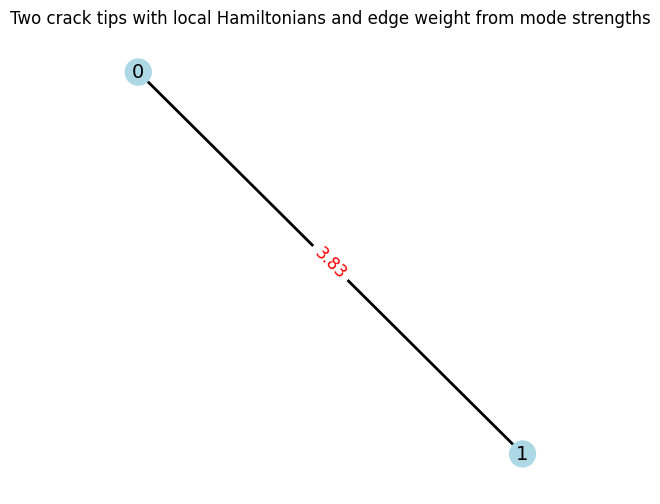

Node 0:
  λ = 0.5
  mode strength s = 3.97279
  H eigenvalues μ_j = [-2.09946397e-02+0.76135828j -2.09946397e-02-0.76135828j
  4.83274853e-14+1.22474487j  4.83274853e-14-1.22474487j]

Node 1:
  λ = 0.8
  mode strength s = 3.68582
  H eigenvalues μ_j = [-3.35914235e-02+0.50014021j -3.35914235e-02-0.50014021j
  1.79642523e-13+1.34164079j  1.79642523e-13-1.34164079j]



In [5]:
# ---------- 4.1: Scalar "mode strength" from the Hamiltonian spectrum ----------

def mode_strength_from_H_eigs(node_data: dict) -> float:
    """
    Given a node's Hamiltonian data (from crack_tip_hamiltonian_data),
    compute a simple scalar 'mode strength' from the eigenvalues of H(λ):

        s = sum_j |μ_j|

    where μ_j are the eigenvalues of H(λ).

    This is NOT a physical fracture energy, just a well-defined scalar
    derived from the local Hamiltonian spectrum that we can use for
    toy graph weighting and visualisation.
    """
    eigvals = node_data["H_eigvals"]
    s = float(np.sum(np.abs(eigvals)))
    return s


# ---------- 4.2: Build a 2-tip graph from the Hamiltonian data ----------

def build_two_tip_graph(C1: np.ndarray,
                        lam1: float,
                        C2: np.ndarray,
                        lam2: float) -> nx.Graph:
    """
    Build a NetworkX graph with two crack-tip nodes (0 and 1),
    each carrying its local Hamiltonian data, and a single edge
    between them whose weight is the average of the node 'mode strengths'.
    """
    G = nx.Graph()

    # Crack-tip data (includes C, Cd, Ce, Cf, H, eigenpairs, λ)
    tip1_data = crack_tip_hamiltonian_data(C1, lam1)
    tip2_data = crack_tip_hamiltonian_data(C2, lam2)

    # Add nodes with their full Hamiltonian payload
    G.add_node(0, **tip1_data)
    G.add_node(1, **tip2_data)

    # Compute scalar "mode strengths" from eigenvalues
    s1 = mode_strength_from_H_eigs(tip1_data)
    s2 = mode_strength_from_H_eigs(tip2_data)

    # Edge weight = average of the two node strengths (well-defined scalar)
    edge_weight = 0.5 * (s1 + s2)

    G.add_edge(0, 1, weight=edge_weight)

    return G


# ---------- 4.3: Apply to a toy anisotropic stiffness example ----------

# Toy anisotropic stiffness (same for both tips here, but λ differs)
C_toy_1 = toy_anisotropic_C()
C_toy_2 = toy_anisotropic_C()   # could be different if you want

lambda_1 = 0.5
lambda_2 = 0.8

G_two_tips = build_two_tip_graph(C_toy_1, lambda_1, C_toy_2, lambda_2)


# ---------- 4.4: Visualise the 2-tip graph with edge weight ----------

pos = nx.spring_layout(G_two_tips, seed=0)  # deterministic layout

plt.figure(figsize=(6, 6))

# Node sizes scaled by their mode strength, just for visual feedback
node_strengths = []
for n, data in G_two_tips.nodes(data=True):
    s = mode_strength_from_H_eigs(data)
    node_strengths.append(s)

# Simple linear scaling for plotting
node_sizes = 300 + 50 * (np.array(node_strengths) / np.max(node_strengths))

nx.draw_networkx_nodes(G_two_tips, pos, node_size=node_sizes, node_color="lightblue")
nx.draw_networkx_labels(G_two_tips, pos, font_size=14)

# Draw edges
nx.draw_networkx_edges(G_two_tips, pos, width=2)

# Edge weight labels
edge_labels = {(u, v): f"{d['weight']:.3g}" for u, v, d in G_two_tips.edges(data=True)}
nx.draw_networkx_edge_labels(G_two_tips, pos, edge_labels=edge_labels,
                             font_color="red", font_size=12)

plt.title("Two crack tips with local Hamiltonians and edge weight from mode strengths")
plt.axis("off")
plt.show()


# ---------- 4.5: Quick inspection of the node Hamiltonian data ----------

for n, data in G_two_tips.nodes(data=True):
    print(f"Node {n}:")
    print(f"  λ = {data['lambda']}")
    print(f"  mode strength s = {mode_strength_from_H_eigs(data):.6g}")
    print(f"  H eigenvalues μ_j = {data['H_eigvals']}")
    print()



## 4. Two anisotropic crack tips → weighted graph for MaxCut

We now close the loop from the anisotropic Hamiltonian to a simple weighted graph
that can be used as input to the MaxCut stage of the pipeline.

For each crack tip, we already compute:

- the local stiffness tensor $C$ in the crack-aligned polar frame,
- the Hamiltonian $H(\lambda)$ from Eq. (46),
- its eigenvalues $\{\mu_j\}$ and eigenvectors.

To compress this local spectral information into a single scalar per node, we define a
simple **mode-strength** quantity
$$
s = \sum_j |\mu_j|,
$$
where the sum runs over all eigenvalues of $H(\lambda)$.

This $s$ is *not* a physical fracture energy; it is a well-defined scalar derived
from the Hamiltonian spectrum that we can use as a toy "importance" measure for the
node in the graph.

For this first example:

- Node 0 and node 1 correspond to two crack tips with the same toy anisotropic
  stiffness $C$ but different chosen singular exponents $\lambda_0$ and $\lambda_1$,
- We define the edge weight between them as the average of their node strengths:
  $$
  w_{01} = \tfrac{1}{2}(s_0 + s_1).
  $$

This produces a simple 2-node weighted graph $(V,E,w)$ that can be passed directly
to a MaxCut routine that accepts a NetworkX graph with a `"weight"` attribute on edges
(e.g. Qiskit’s MaxCut examples).


In [6]:
import numpy as np

def mode_strength_from_H_eigs(node_data: dict) -> float:
    """
    Given a node's Hamiltonian data (from crack_tip_hamiltonian_data),
    compute a scalar 'mode strength' from the eigenvalues of H(λ):

        s = sum_j |μ_j|

    where μ_j are the eigenvalues of H(λ).

    This is explicitly defined as a toy scalar for weighting the graph.
    """
    eigvals = node_data["H_eigvals"]
    s = float(np.sum(np.abs(eigvals)))
    return s

## 5. Crack boundary-value problem for a straight anisotropic crack

We now solve a simple boundary-value problem (BVP) for a straight crack in a
homogeneous anisotropic medium, using the Hamiltonian $H(\lambda)$ from Eq. (46).

Geometry:
- Crack is aligned with the $x$-axis.
- The two crack faces correspond to polar angles $\theta_- = -\pi$ and $\theta_+ = +\pi$.

State:
$$
\psi(\theta) =
\begin{bmatrix}
q(\theta) \\
p(\theta)
\end{bmatrix}
=
\begin{bmatrix}
u_r(\theta) \\
u_\theta(\theta) \\
S_r(\theta) \\
S_\theta(\theta)
\end{bmatrix}.
$$

We impose **traction-free faces**:
$$
p(-\pi) = 0, \qquad p(+\pi) = 0.
$$

For a fixed $\lambda$, the Hamiltonian ODE
$$
\frac{d\psi}{d\theta} = H(\lambda)\,\psi
$$
with constant $H(\lambda)$ has the solution
$$
\psi(\theta_+) = P(\lambda)\,\psi(\theta_-),
\qquad
P(\lambda) = \exp\big(H(\lambda)\,\Delta\theta\big),
\quad \Delta\theta = 2\pi.
$$

We enforce:
- At $\theta_-$, $p(-\pi) = 0$ and $q(-\pi)$ is free:
  $$
  \psi_- =
  \begin{bmatrix}
  q_0 \\
  0
  \end{bmatrix}.
  $$
- At $\theta_+$, we require $p(+\pi) = 0$.

Writing $P(\lambda)$ in block form,
$$
P(\lambda) =
\begin{pmatrix}
P_{qq}(\lambda) & P_{qp}(\lambda) \\
P_{pq}(\lambda) & P_{pp}(\lambda)
\end{pmatrix},
$$
we obtain
$$
p(+\pi) = P_{pq}(\lambda)\,q_0.
$$

For a nontrivial $q_0$ to exist, we require
$$
\det P_{pq}(\lambda) = 0.
$$

This defines the **crack-tip eigenvalue problem for $\lambda$**. We solve it numerically
by scanning over a range of $\lambda$ values and searching for minima of
$|\det P_{pq}(\lambda)|$.


In [7]:
def angular_propagator(Cd: np.ndarray, Cf: np.ndarray, lam: float, dtheta: float = 2*np.pi) -> np.ndarray:
    """
    Compute the 4x4 angular propagator:
        P(λ) = exp(H(λ) * Δθ)
    using eigen-decomposition of H(λ):
        H = V diag(μ_j) V^{-1}
        P = V diag(exp(μ_j Δθ)) V^{-1}
    """
    H = build_H_lambda(Cd, Cf, lam)
    eigvals, eigvecs = np.linalg.eig(H)

    V = eigvecs
    Vinv = np.linalg.inv(V)
    exp_diag = np.diag(np.exp(eigvals * dtheta))

    P = V @ exp_diag @ Vinv
    return P


def bc_det_for_lambda(C: np.ndarray, lam: float, dtheta: float = 2*np.pi) -> complex:
    """
    For a given 3x3 stiffness C and scalar λ, compute the determinant
    of the P_pq(λ) block associated with the crack boundary conditions:
        det P_pq(λ)

    Here P(λ) = angular propagator from θ=-π to θ=+π.
    """
    Cd, Ce, Cf = extract_C_blocks(C)
    P = angular_propagator(Cd, Cf, lam, dtheta=dtheta)

    # P is 4x4: partition into blocks
    P_pq = P[2:4, 0:2]  # rows for p(+π), columns for q(-π)

    return np.linalg.det(P_pq)


def find_lambda_crack(C: np.ndarray,
                      lam_min: float = 0.1,
                      lam_max: float = 1.0,
                      n_samples: int = 400):
    """
    Scan λ in [lam_min, lam_max] and find the value that minimises
    |det P_pq(λ)|.

    Returns:
        lam_star: λ at minimum
        det_min: |det P_pq(λ_star)|
        lam_grid: sampled λ values
        det_vals: corresponding |det P_pq(λ)|
    """
    lam_grid = np.linspace(lam_min, lam_max, n_samples)
    det_vals = np.empty_like(lam_grid, dtype=float)

    for i, lam in enumerate(lam_grid):
        det_val = bc_det_for_lambda(C, lam)
        det_vals[i] = np.abs(det_val)

    idx_min = int(np.argmin(det_vals))
    lam_star = float(lam_grid[idx_min])
    det_min = float(det_vals[idx_min])

    return lam_star, det_min, lam_grid, det_vals


Node data:
  Node 0: λ = 0.5000, mode strength s = 3.97279
    H eigenvalues μ_j = [-2.09946397e-02+0.76135828j -2.09946397e-02-0.76135828j
  4.83274853e-14+1.22474487j  4.83274853e-14-1.22474487j]

  Node 1: λ = 0.8000, mode strength s = 3.68582
    H eigenvalues μ_j = [-3.35914235e-02+0.50014021j -3.35914235e-02-0.50014021j
  1.79642523e-13+1.34164079j  1.79642523e-13-1.34164079j]

Edges with weights:
  Edge (0,1): weight = 3.8293



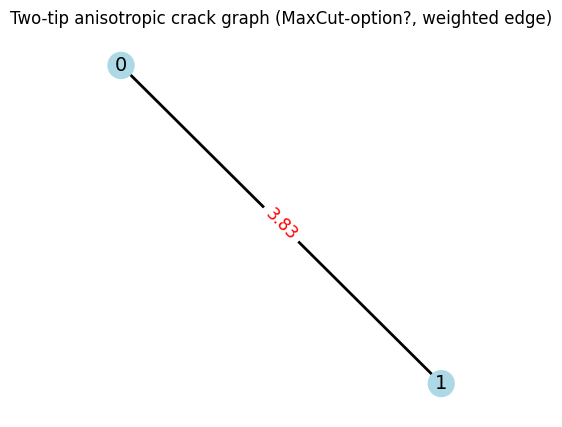

Weighted edges for MaxCut: [(0, 1, 3.8293003567764394)]
Adjacency matrix for MaxCut:
[[0.         3.82930036]
 [3.82930036 0.        ]]


In [ ]:
# -------------------------------------------------------
# 1. Helper: node "mode strength" from Hamiltonian eigenvalues
# -------------------------------------------------------

def mode_strength_from_H_eigs(node_data: dict) -> float:
    """
    Given a node's Hamiltonian data (from crack_tip_hamiltonian_data),
    compute a scalar 'mode strength' from the eigenvalues of H(λ):

        s = sum_j |μ_j|

    This is a defined toy scalar for weighting the graph (MaxCut).
    """
    eigvals = node_data["H_eigvals"]
    return float(np.sum(np.abs(eigvals)))


# -------------------------------------------------------
# 2. Build the 2-node MaxCut-ready graph
# -------------------------------------------------------

def build_two_tip_graph_for_maxcut(C: np.ndarray,
                                   lam1: float,
                                   lam2: float) -> nx.Graph:
    """
    Build a NetworkX graph with two crack-tip nodes (0 and 1), each carrying
    its Hamiltonian data, and a single edge whose 'weight' is the average of
    the two node mode strengths.

    This graph is directly compatible with MaxCut routines that expect
    nx.Graph with a 'weight' attribute on edges.
    """
    G = nx.Graph()

    # Local crack-tip Hamiltonian data for each node
    tip1_data = crack_tip_hamiltonian_data(C, lam1)
    tip2_data = crack_tip_hamiltonian_data(C, lam2)

    # Attach full payloads
    G.add_node(0, **tip1_data)
    G.add_node(1, **tip2_data)

    # Node strengths from H(λ) eigenvalues
    s1 = mode_strength_from_H_eigs(tip1_data)
    s2 = mode_strength_from_H_eigs(tip2_data)

    # Edge weight = average of node strengths
    edge_weight = 0.5 * (s1 + s2)

    G.add_edge(0, 1, weight=edge_weight)

    return G


# -------------------------------------------------------
# 3. Instantiate the graph with a toy anisotropic stiffness
# -------------------------------------------------------

# Use the same toy anisotropic C for both tips (you can change this later)
C_toy = toy_anisotropic_C()

lambda_0 = 0.5
lambda_1 = 0.8

G_maxcut = build_two_tip_graph_for_maxcut(C_toy, lambda_0, lambda_1)

# -------------------------------------------------------
# 4. Inspect nodes and edge weights (sanity check)
# -------------------------------------------------------

print("Node data:")
for n, data in G_maxcut.nodes(data=True):
    s = mode_strength_from_H_eigs(data)
    print(f"  Node {n}: λ = {data['lambda']:.4f}, mode strength s = {s:.6g}")
    print(f"    H eigenvalues μ_j = {data['H_eigvals']}")
    print()

print("Edges with weights:")
for u, v, d in G_maxcut.edges(data=True):
    print(f"  Edge ({u},{v}): weight = {d['weight']:.6g}")
print()

# -------------------------------------------------------
# 5. Visualise the 2-node MaxCut graph
# -------------------------------------------------------

pos = nx.spring_layout(G_maxcut, seed=0)  # deterministic layout

plt.figure(figsize=(5,5))

# Node sizes scaled by mode strength (optional, just for visual feedback)
node_strengths = [mode_strength_from_H_eigs(data) for _, data in G_maxcut.nodes(data=True)]
node_sizes = 300 + 50 * (np.array(node_strengths) / np.max(node_strengths))

nx.draw_networkx_nodes(G_maxcut, pos, node_size=node_sizes, node_color="lightblue")
nx.draw_networkx_labels(G_maxcut, pos, font_size=14)
nx.draw_networkx_edges(G_maxcut, pos, width=2)

edge_labels = {(u, v): f"{d['weight']:.3g}" for u, v, d in G_maxcut.edges(data=True)}
nx.draw_networkx_edge_labels(G_maxcut, pos, edge_labels=edge_labels,
                             font_color="red", font_size=12)

plt.title("Two-tip anisotropic crack graph (MaxCut-option?, weighted edge)")
plt.axis("off")
plt.show()

# -------------------------------------------------------
# 6. Export in a MaxCut-friendly format
# -------------------------------------------------------

weighted_edges = [(u, v, d["weight"]) for u, v, d in G_maxcut.edges(data=True)]
adj_matrix = nx.to_numpy_array(G_maxcut, weight="weight")

print("Weighted edges for MaxCut:", weighted_edges)
print("Adjacency matrix for MaxCut:")
print(adj_matrix)


Trying to see if I can get energy release as edge weights.  Still need to find equations for finding SIF and Energy release.

Updated edge with relative energy-release rate:
  Edge (0,1): G_relative = 14.6841, weight = 14.6841


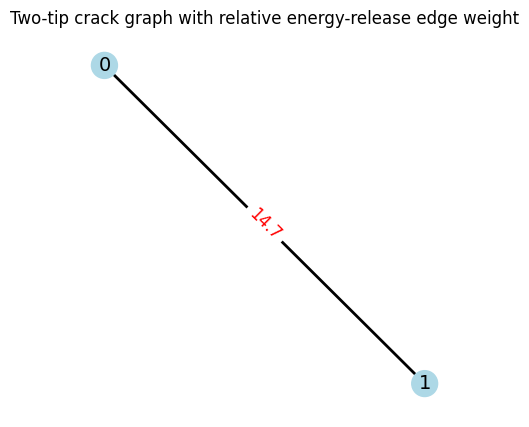

In [14]:
# -------------------------------------------------------
# 5. Redefine edge weight as relative energy release rate
# -------------------------------------------------------

def relative_energy_release_from_nodes(node_data_1: dict,
                                       node_data_2: dict,
                                       E_eff: float = 1.0) -> float:
    """
    Compute a *relative* energy-release-like quantity for the edge connecting
    two crack-tip nodes. This preserves the physical idea that energy release
    scales ∝ K_I^2 + K_II^2 while remaining compatible with the toy Hamiltonian
    model.

    We use the node 'mode strengths':
        s_i = sum_j |μ_j|
    Then define:
        G_i,rel = s_i^2
        G_edge,rel = 0.5 * (G_i,rel + G_j,rel) / E_eff

    E_eff acts as a placeholder (1 / effective modulus); default = 1.0.
    """
    s1 = mode_strength_from_H_eigs(node_data_1)
    s2 = mode_strength_from_H_eigs(node_data_2)

    G1_rel = s1**2
    G2_rel = s2**2

    G_edge_rel = 0.5 * (G1_rel + G2_rel) / E_eff
    return float(G_edge_rel)


# Update the single edge of G_maxcut
edges = list(G_maxcut.edges(data=True))
if len(edges) != 1:
    raise ValueError(f"Expected exactly one edge, found {len(edges)}.")

u, v, d = edges[0]

node_u = G_maxcut.nodes[u]
node_v = G_maxcut.nodes[v]

# Compute relative energy release
G_rel = relative_energy_release_from_nodes(node_u, node_v)

# Store as an attribute AND use it as the weighted value for MaxCut
G_maxcut[u][v]["G_relative"] = G_rel
G_maxcut[u][v]["weight"] = G_rel

print("Updated edge with relative energy-release rate:")
print(f"  Edge ({u},{v}): G_relative = {G_rel:.6g}, weight = {G_maxcut[u][v]['weight']:.6g}")


# -------------------------------------------------------
# 5b. Visualise the updated graph with the new weight
# -------------------------------------------------------

pos = nx.spring_layout(G_maxcut, seed=0)

plt.figure(figsize=(5,5))

# Node sizes still scale by mode strength
node_strengths = [mode_strength_from_H_eigs(data) for _, data in G_maxcut.nodes(data=True)]
node_sizes = 300 + 50 * (np.array(node_strengths) / np.max(node_strengths))

nx.draw_networkx_nodes(G_maxcut, pos, node_size=node_sizes, node_color="lightblue")
nx.draw_networkx_labels(G_maxcut, pos, font_size=14)
nx.draw_networkx_edges(G_maxcut, pos, width=2)

# Show the new energy-based edge weight
edge_labels = {(u, v): f"{G_rel:.3g}"}  
nx.draw_networkx_edge_labels(G_maxcut, pos, edge_labels=edge_labels,
                             font_color="red", font_size=12)

plt.title("Two-tip crack graph with relative energy-release edge weight")
plt.axis("off")
plt.show()


**What is not fully physical and needs updating:**

1. **Mode strengths (`s = Σ|μ_j|`) are not real SIFs.**  
   They must be replaced by actual \(K_I, K_{II}\) computed from eigenvectors + geometry.

2. **Energy-release formula uses \(s^2\)** as a proxy.  
   It must be replaced with  
   $$G = \frac{1-\nu^2}{E}(K_I^2 + K_{II}^2)$$

3. **No geometric dependence** (distance, crack orientation, notch angle).  
   These must be included when converting λ/eigenmodes to SIFs.

4. **No coupling with external loads** (remote stress, gravity, boundary constraints).  
   These need to be incorporated to get correct SIFs.

5. **Hamiltonian parameters not yet tied to material constants.**  
   C-matrix must map directly into physical stiffness values.

6. **Single-edge averaging is a placeholder.**  
   Real multi-tip interactions require superposition or FEM-derived influence functions.
